In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# Verificar versión de XGBoost y disponibilidad de GPU
print(f"XGBoost version: {xgb.__version__}")
print(f"GPU Support: {xgb.build_info()['USE_CUDA']}") # Debería mostrar True o 1

XGBoost version: 3.3.0
GPU Support: True


In [2]:
# Cargar el dataset (ajusta la ruta si es necesario)
df = pd.read_csv('../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

# Renombrar variable objetivo y limpiar
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Eliminar la columna ID (no tiene poder predictivo)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

display(df.head())

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# 1. Separar variables
X = df.drop('default', axis=1)
y = df['default']

# 2. Dividir en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

Tamaño del set de entrenamiento: (24000, 23)
Tamaño del set de prueba: (6000, 23)


In [4]:
# Calcular el peso para balancear las clases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Scale Pos Weight calculado: {scale_pos_weight:.2f}")

# Definir el modelo XGBoost
model = xgb.XGBClassifier(
    n_estimators=500,           # Número de árboles
    max_depth=6,                # Profundidad máxima de cada árbol
    learning_rate=0.05,         # Tasa de aprendizaje (más baja = mejor generalización)
    subsample=0.8,              # Muestreo de filas por árbol
    colsample_bytree=0.8,       # Muestreo de columnas por árbol
    scale_pos_weight=scale_pos_weight, # Manejo de desbalance
    tree_method='hist',         # Algoritmo óptimo para GPU
    device='cuda',              # ¡Habilitar GPU! (Requiere XGBoost >= 2.0)
    eval_metric='aucpr',        # Métrica a optimizar (Area Under Precision-Recall)
    early_stopping_rounds=50,   # Parar si no mejora en 50 rondas
    random_state=42,
    verbosity=1
)

Scale Pos Weight calculado: 3.52


In [6]:
# Entrenar el modelo pasando el set de validación para el Early Stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=10 # Mostrar logs cada 10 rondas
)

[0]	validation_0-aucpr:0.52519
[10]	validation_0-aucpr:0.54744


[20]	validation_0-aucpr:0.54692
[30]	validation_0-aucpr:0.54881
[40]	validation_0-aucpr:0.55028
[50]	validation_0-aucpr:0.54884
[60]	validation_0-aucpr:0.55267
[70]	validation_0-aucpr:0.55469
[80]	validation_0-aucpr:0.55547
[90]	validation_0-aucpr:0.55696
[100]	validation_0-aucpr:0.55719
[110]	validation_0-aucpr:0.55590
[120]	validation_0-aucpr:0.55578
[130]	validation_0-aucpr:0.55560
[140]	validation_0-aucpr:0.55543
[148]	validation_0-aucpr:0.55492


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


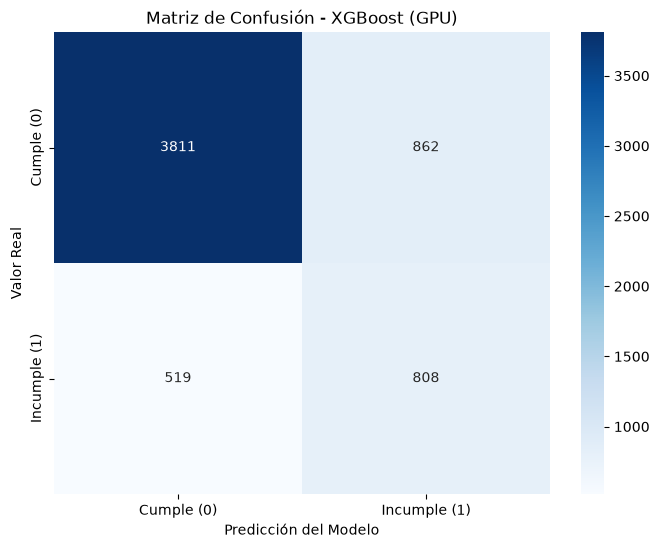

In [7]:
# Obtener predicciones
y_pred_prob = model.predict_proba(X_test)[:, 1] # Probabilidades de la clase 1
y_pred = model.predict(X_test) # Clases binarias

# --- MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cumple (0)', 'Incumple (1)'], 
            yticklabels=['Cumple (0)', 'Incumple (1)'])
plt.title('Matriz de Confusión - XGBoost (GPU)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()



In [8]:
# --- REPORTE DE CLASIFICACIÓN ---
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Cumple (0)', 'Incumple (1)']))


Reporte de Clasificación:
              precision    recall  f1-score   support

  Cumple (0)       0.88      0.82      0.85      4673
Incumple (1)       0.48      0.61      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



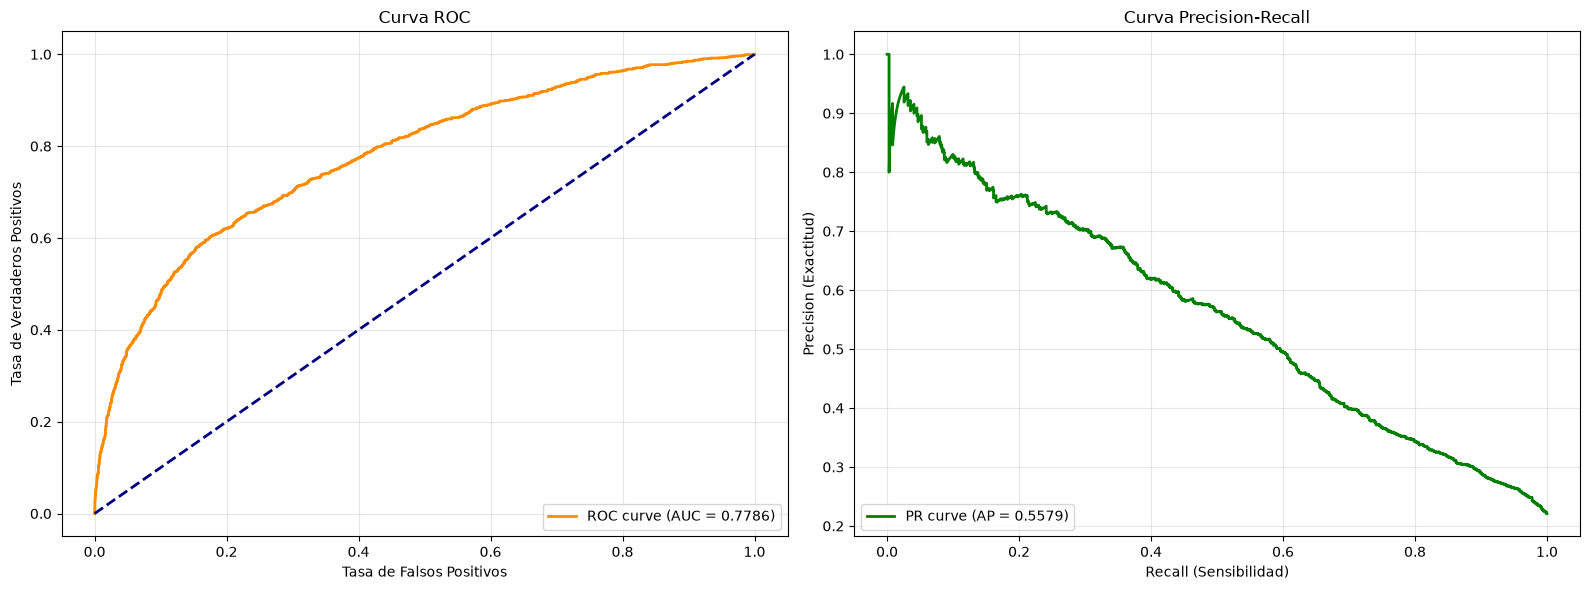

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.set_title('Curva ROC')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# 2. Curva Precision-Recall (Crítica en datos desbalanceados)
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax2.set_xlabel('Recall (Sensibilidad)')
ax2.set_ylabel('Precision (Exactitud)')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

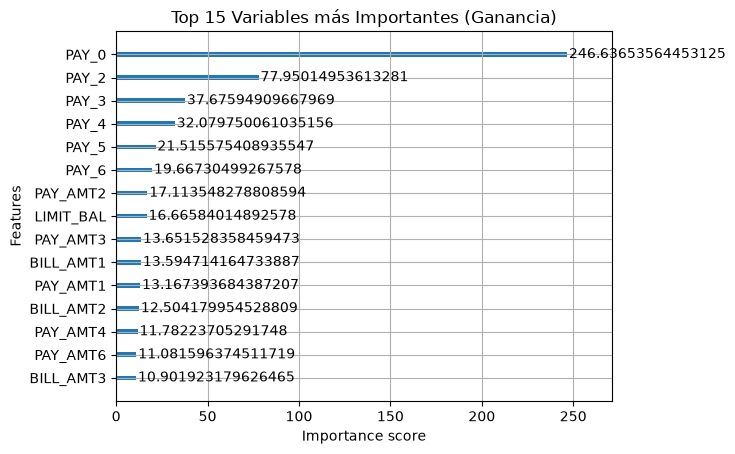

In [10]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15, importance_type='gain', 
                    title='Top 15 Variables más Importantes (Ganancia)')
plt.show()